# DynTrust-FedIDS++ -- Real-Data, Real-Baseline Pipeline (Corrected)

**What changed vs. the original notebook, and why.** The original pipeline used 100% synthetic
Gaussian data (no real dataset), implemented none of the paper's claimed baseline aggregators
(FedAvg, Median, Trimmed Mean, Krum, Multi-Krum, static Trust-Weighted Krum), had no ALIE or
FGSM attack, no audit ledger, no real FISTA solver for the "optimization-based aggregation"
(it was a one-shot weighted blend), and hardcoded `pos_label=0` as "the minority class" for
every client regardless of that client's actual class balance -- silently wrong for 7 of 10
of the paper's own described clients. Every one of these is fixed below and tested end-to-end
in a real Python sandbox before being placed in this notebook (not just written and hoped to
work).

**Dataset scope, stated honestly.** The paper claims CIC-IDS2017, CIC-IoT-2023, and BoT-IoT.
Those specific files were not available; what *is* available (from prior work in this project)
are 4 real, flow-level datasets: NF-CSE-CIC-IDS2018, NF-ToN-IoT, UNSW-NB15, and CIDDS-001.
These are substituted in and the paper's dataset section should be corrected to say so --
this notebook does not pretend they are the originally-named datasets.

**Feature space, stated honestly.** The paper aspires to 25 common numeric features across
its 3 datasets. Across these 4 real datasets, only 5 genuinely common flow-statistics can be
harmonized (duration, total bytes, total packets, bytes/packet, packets/second) -- computed
from each dataset's own native columns. This is real and defensible, but smaller than 25;
stated as a scope limitation, not hidden.

**Convergence, stated honestly.** Testing in the sandbox showed the model/FedAvg combination
needs roughly 30-40 communication rounds to reach a reasonable balanced accuracy on clearly
separable synthetic sanity data -- NOT the 8-12 rounds the original paper claimed. Round
budgets below are set accordingly.

## 0. Environment Setup

In [ ]:
!pip install -q torch scipy scikit-learn pandas matplotlib pyarrow

import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

Torch: 2.11.0+cu128 | CUDA available: True


## 0b. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive'  # EDIT if your files are in a subfolder

import zipfile, glob
EXTRACT_DIR = '/content/extracted'
os.makedirs(EXTRACT_DIR, exist_ok=True)
extracted_files = {}
for zp in sorted(glob.glob(os.path.join(DATA_DIR, 'archive*.zip'))):
    with zipfile.ZipFile(zp) as z:
        for member in z.namelist():
            if member.endswith('/'):
                continue
            base = os.path.basename(member)
            target = os.path.join(EXTRACT_DIR, base)
            if not os.path.exists(target):
                with z.open(member) as src, open(target, 'wb') as dst:
                    dst.write(src.read())
            extracted_files[base] = target
for f in os.listdir(DATA_DIR):
    if f.lower().endswith(('.csv', '.parquet')):
        extracted_files[f] = os.path.join(DATA_DIR, f)
print("Available files:", list(extracted_files.keys()))

Mounted at /content/drive
Available files: ['cidds-001-externalserver.parquet', 'cidds-001-openstack.parquet', 'NF-ToN-IoT.parquet', 'NF-CSE-CIC-IDS2018.parquet', 'DNN-EdgeIIoT-dataset.csv', 'ML-EdgeIIoT-dataset.csv', 'live_data_training.csv', 'UNSW_NB15_testing-set.parquet', 'UNSW_NB15_training-set.parquet']


## 1. Byzantine Attacks (real multi-type: sign-flip, Gaussian, ALIE)

FIX: the original notebook only implemented an unconditional sign-flip. All three attack types
the paper's Attack Model (Section 4) describes are implemented here, including ALIE (Baruch,
Baruch & Goldberg 2019) which crafts updates from the honest clients' own empirical mean/std --
specifically designed to be harder for simple outlier-based defences (like Krum) to catch than
a crude sign-flip or large Gaussian perturbation.

In [ ]:
"""
Byzantine attack implementations for DynTrust-FedIDS++.

FIX vs. original notebook: the only "attack" implemented there was an unconditional sign-flip
applied to a fixed prefix of client IDs. The paper (Section 4, Attack model) claims THREE attack
types -- sign-flip, additive Gaussian noise, and ALIE (A Little Is Enough, Baruch et al. 2019) --
selectable and configurable. This module actually implements all three.
"""
import torch


def sign_flip_attack(state_dict, scale=1.0):
    """Delta w <- -scale * Delta w (relative to the update each client sends)."""
    return {k: -scale * v for k, v in state_dict.items()}


def gaussian_noise_attack(state_dict, sigma=1.0):
    """Delta w <- Delta w + N(0, sigma^2 I), applied per-parameter."""
    return {k: v + torch.randn_like(v) * sigma for k, v in state_dict.items()}


def alie_attack(honest_updates, z_max=1.5):
    """A Little Is Enough (Baruch, Baruch & Goldberg, 2019): craft a single malicious update
    using the empirical mean and per-coordinate std of the HONEST updates, shifted by z_max
    standard deviations -- designed to be small enough per-coordinate to evade simple outlier
    detectors (like Krum) while still biasing the aggregate.
    honest_updates: list of state_dicts (already-collected local updates from honest clients
    this round). Returns a single crafted state_dict.
    """
    keys = honest_updates[0].keys()
    n = len(honest_updates)
    crafted = {}
    for k in keys:
        stacked = torch.stack([u[k].float() for u in honest_updates])  # (n, *param_shape)
        mean = stacked.mean(dim=0)
        std = stacked.std(dim=0, unbiased=False)
        crafted[k] = mean - z_max * std  # shift against the mean, within honest std envelope
    return crafted


def apply_attack(state_dict, attack_type, honest_updates_so_far=None, sigma_a=1.0, z_max=1.5):
    """Dispatch. For ALIE, honest_updates_so_far must be provided (other honest clients'
    updates already collected this round) -- if none are available yet, falls back to a
    Gaussian attack as a reasonable degradation rather than crashing."""
    if attack_type == 'sign_flip':
        return sign_flip_attack(state_dict)
    elif attack_type == 'gaussian':
        return gaussian_noise_attack(state_dict, sigma=sigma_a)
    elif attack_type == 'alie':
        if honest_updates_so_far and len(honest_updates_so_far) >= 2:
            return alie_attack(honest_updates_so_far, z_max=z_max)
        return gaussian_noise_attack(state_dict, sigma=sigma_a)
    else:
        raise ValueError(f"unknown attack_type {attack_type}")


## 2. Aggregators: Real Baselines + Genuine Iterative Optimization Aggregator

FIX: the paper claims comparison against FedAvg, Median, Trimmed Mean, Krum, Multi-Krum, and a
static Trust-Weighted Krum baseline -- none were implemented; only the proposed method's own
aggregator existed. All are implemented here so RQ2 is actually testable.

FIX: the paper's Section 3.5.1 claims a convex objective solved by FISTA (accelerated proximal
gradient) to a 1e-6 tolerance within <=25 iterations. The original code was a one-shot weighted
blend with no iteration at all. This module actually runs FISTA and returns the real iteration
count and final gradient norm, so the convergence claim is checkable, not assumed.

In [ ]:
"""
Aggregation rules for DynTrust-FedIDS++.

FIX vs. original notebook: the paper claims comparison against FedAvg, Median, Trimmed Mean,
Krum, Multi-Krum, and a static Trust-Weighted Krum baseline -- none of these were implemented;
the notebook only had the proposed method's own aggregator. All are implemented here so RQ2
(does optimization-based adaptive aggregation outperform fixed robust aggregators?) is actually
testable.

FIX vs. original notebook's "optimization_based_aggregate": the paper's Section 3.5.1 claims a
convex, trust-weighted objective f(w) = sum_k tau_k ||w - w_k||^2 + lambda * Omega(w) solved by
accelerated proximal gradient descent (FISTA) to a 1e-6 tolerance within <=25 iterations. The
original code did none of that -- it was a single-shot weighted-mean/coordinate-median blend
with a hand-picked mixing constant, no iteration, no convergence check. This module actually
runs FISTA on the stated objective, using a smooth Huber-style regularizer anchored to the
coordinate-median, and returns real iteration counts and final gradient norm so the "M <= 25
iterations, 1e-6 tolerance" claim is checkable, not assumed.
"""
import torch


def _flatten(sd):
    keys = list(sd.keys())
    shapes = {k: sd[k].shape for k in keys}
    flat = torch.cat([sd[k].flatten().float() for k in keys])
    return flat, keys, shapes


def _unflatten(flat, keys, shapes):
    out = {}
    i = 0
    for k in keys:
        n = int(torch.tensor(shapes[k]).prod().item())
        out[k] = flat[i:i + n].reshape(shapes[k])
        i += n
    return out


def fedavg(updates, weights=None):
    n = len(updates)
    if weights is None:
        weights = [1.0 / n] * n
    out = {}
    for k in updates[0]:
        out[k] = sum(w * u[k].float() for w, u in zip(weights, updates))
    return out


def coordinate_median(updates):
    out = {}
    for k in updates[0]:
        stacked = torch.stack([u[k].float() for u in updates])
        out[k] = stacked.median(dim=0).values
    return out


def trimmed_mean(updates, trim_frac=0.2):
    n = len(updates)
    k_trim = max(0, int(n * trim_frac))
    out = {}
    for k in updates[0]:
        stacked = torch.stack([u[k].float() for u in updates])
        sorted_vals, _ = stacked.sort(dim=0)
        if 2 * k_trim < n:
            trimmed = sorted_vals[k_trim: n - k_trim]
        else:
            trimmed = sorted_vals
        out[k] = trimmed.mean(dim=0)
    return out


def krum(updates, f):
    n = len(updates)
    flats = [_flatten(u)[0] for u in updates]
    n_neighbors = max(1, n - f - 2)
    scores = []
    for i in range(n):
        dists = sorted(((flats[i] - flats[j]).pow(2).sum().item() for j in range(n) if j != i))
        scores.append(sum(dists[:n_neighbors]))
    best = int(torch.tensor(scores).argmin().item())
    return updates[best], best


def multi_krum(updates, f, m=None):
    n = len(updates)
    if m is None:
        m = max(1, n - f)
    flats = [_flatten(u)[0] for u in updates]
    n_neighbors = max(1, n - f - 2)
    scores = []
    for i in range(n):
        dists = sorted(((flats[i] - flats[j]).pow(2).sum().item() for j in range(n) if j != i))
        scores.append(sum(dists[:n_neighbors]))
    order = sorted(range(n), key=lambda i: scores[i])[:m]
    selected = [updates[i] for i in order]
    return fedavg(selected), order


def static_trust_weighted_krum(updates, trust_scores, f):
    _, order = multi_krum(updates, f)
    selected = [updates[i] for i in order]
    sel_trust = [trust_scores[i] for i in order]
    total = sum(sel_trust) + 1e-12
    weights = [t / total for t in sel_trust]
    return fedavg(selected, weights=weights)


def _huber_grad(x, delta=1.0):
    absx = x.abs()
    return torch.where(absx <= delta, x, delta * x.sign())


def optimization_based_aggregate(updates, trust_scores, lambda_reg=0.15, max_iter=25, tol=1e-6,
                                  huber_delta=1.0):
    n = len(updates)
    tau = torch.tensor(trust_scores, dtype=torch.float64)
    tau = tau / (tau.sum() + 1e-12)

    flats = [_flatten(u)[0].double() for u in updates]
    keys, shapes = _flatten(updates[0])[1:]
    W = torch.stack(flats)
    median_w = W.median(dim=0).values

    L = 2.0 + lambda_reg
    step = 1.0 / L

    w = W.mean(dim=0).clone()
    z = w.clone()
    t_k = 1.0
    grad_norm = float('inf')
    it_used = 0
    for it in range(max_iter):
        it_used = it + 1
        grad_smooth = 2.0 * (tau.unsqueeze(1) * (z.unsqueeze(0) - W)).sum(dim=0)
        grad_reg = lambda_reg * _huber_grad(z - median_w, delta=huber_delta)
        grad = grad_smooth + grad_reg
        grad_norm = grad.norm().item()
        w_new = z - step * grad
        t_next = (1 + (1 + 4 * t_k ** 2) ** 0.5) / 2
        z = w_new + ((t_k - 1) / t_next) * (w_new - w)
        moved = (w_new - w).norm().item()
        w = w_new
        t_k = t_next
        if moved < tol:
            break

    out = _unflatten(w.float(), keys, shapes)
    return out, it_used, grad_norm


## 3. Drift-Aware Multi-Criteria Trust Manager (reference-leakage bug fixed)

FIX: the original computed the "honest reference" embedding by averaging embeddings that
already included the CURRENT client's own embedding -- a self-comparison bug that diluted the
exact drift signal r_drift is supposed to detect, in an order-dependent way. This version
maintains a persistent reference, updated once per round from the PREVIOUS round's trusted
clients only, so no client's drift score is ever partly computed against itself.

In [ ]:
"""
Drift-aware multi-criteria trust manager for DynTrust-FedIDS++.

FIX vs. original notebook: `ref_emb = np.mean(emb_list, axis=0) if emb_list else emb` was
computed INSIDE the per-client loop, AFTER the current client's own embedding had already been
appended to emb_list. This means every client's drift residual was partly measured against
itself (self-comparison), diluting exactly the signal r_drift is supposed to catch, and the
dilution differs by client processing order within the round -- a real, order-dependent bug.

Fix: maintain a persistent reference embedding, updated ONCE per round using only the clients
that were trusted in the PREVIOUS round (or all clients on the very first round, before any
trust signal exists), never including the current client's own current-round embedding. This
also better matches the paper's own description: "distributional shift ... relative to a
reference distribution of honest clients" -- honest per the LAST verified trust state, not
including the very sample being scored.
"""
import numpy as np
from scipy.stats import wasserstein_distance


class DriftAwareTrustManager:
    def __init__(self, n_clients, alpha=0.7, betas=(0.25, 0.25, 0.1, 0.15, 0.25),
                 ref_momentum=0.3, trust_threshold_quantile=0.5, gamma=5.0, theta=0.35):
        self.tau = {cid: 1.0 for cid in range(n_clients)}
        self.alpha = alpha
        self.betas = betas
        self.hist_contrib = {cid: 0.0 for cid in range(n_clients)}
        self.last_active = {cid: 0 for cid in range(n_clients)}
        self.ref_embedding = None          # FIX: persistent, round-boundary-only reference
        self.ref_momentum = ref_momentum
        self.trust_threshold_quantile = trust_threshold_quantile
        self.gamma = gamma
        self.theta = theta

    def update(self, cid, val_acc, update_norm, ref_norm, round_idx):
        """Score client cid using ONLY the fixed (pre-round) reference embedding -- embeddings
        are supplied separately via `score_round` below, which owns the reference-update
        timing. This method handles the non-drift residuals + final trust combination."""
        r_perf = 1.0 - val_acc
        r_grad = abs(update_norm - ref_norm) / (ref_norm + 1e-8)
        inactivity = max(0, round_idx - self.last_active[cid] - 1)
        r_temp = min(1.0, inactivity / 5.0)
        r_hist = abs(self.hist_contrib[cid] - val_acc)
        return r_perf, r_grad, r_temp, r_hist

    def compute_drift_residual(self, client_emb):
        """FIX: uses self.ref_embedding as fixed at the END of the previous round -- never the
        current round's own in-progress embeddings, so no self-comparison leakage."""
        if self.ref_embedding is None:
            return 0.0  # no reference yet (round 0): drift is uninformative, not penalized
        try:
            r_drift = float(wasserstein_distance(client_emb.ravel()[:200],
                                                   self.ref_embedding.ravel()[:200]))
            return min(1.0, r_drift / 5.0)
        except Exception:
            return 0.0

    def score_round(self, round_idx, client_ids, val_accs, update_norms, ref_norm, embeddings):
        """Score every client in the round using the FIXED pre-round reference, then update the
        reference for the NEXT round from this round's trusted subset. Returns dict cid->(tau,
        r_drift) and updates self.tau / self.hist_contrib / self.last_active in place."""
        b1, b2, b3, b4, b5 = self.betas
        results = {}
        for cid, val_acc, upd_norm, emb in zip(client_ids, val_accs, update_norms, embeddings):
            r_perf, r_grad, r_temp, r_hist = self.update(cid, val_acc, upd_norm, ref_norm, round_idx)
            r_drift = self.compute_drift_residual(emb)
            risk = b1 * r_perf + b2 * r_grad + b3 * r_temp + b4 * r_hist + b5 * r_drift
            tilde = 1.0 / (1.0 + np.exp(self.gamma * (risk - self.theta)))
            self.tau[cid] = self.alpha * self.tau[cid] + (1 - self.alpha) * tilde
            self.hist_contrib[cid] = 0.8 * self.hist_contrib[cid] + 0.2 * val_acc
            self.last_active[cid] = round_idx
            results[cid] = (self.tau[cid], r_drift)

        # FIX: update the reference embedding ONCE per round, from clients trusted THIS round
        # (trust >= median), using an EMA so it adapts slowly rather than being fully
        # overwritten each round (protects against a majority-Byzantine round corrupting the
        # reference outright).
        trusts_this_round = np.array([results[cid][0] for cid in client_ids])
        thresh = np.quantile(trusts_this_round, self.trust_threshold_quantile)
        trusted_embs = [emb for cid, emb in zip(client_ids, embeddings) if results[cid][0] >= thresh]
        if trusted_embs:
            new_ref = np.mean(trusted_embs, axis=0)
            if self.ref_embedding is None:
                self.ref_embedding = new_ref
            else:
                self.ref_embedding = (self.ref_momentum * self.ref_embedding
                                       + (1 - self.ref_momentum) * new_ref)
        return results

    def trusted_set(self, client_ids, min_trust=None):
        """Clients whose current trust is above min_trust (defaults to the median trust this
        round) -- implements 'clients whose trust falls below a dynamic threshold are
        temporarily excluded' (Section 3.4)."""
        trusts = [self.tau[cid] for cid in client_ids]
        if min_trust is None:
            min_trust = float(np.median(trusts))
        return [cid for cid in client_ids if self.tau[cid] >= min_trust]


## 4. Evaluation (per-client dynamic minority-class fix + full diagnostics)

FIX: the original hardcoded `pos_label=0` (benign) as "the minority class" for every client -- silently wrong for clients where attack is the minority. This version determines the minority class from the actual label distribution of each evaluation batch.

**FIX (reviewer priority #1, diagnostic instrumentation):** a collapsed classifier (predicting one class for every input) produces BAcc=0.500 and minority_recall=0.000 -- indistinguishable from "the attack/aggregator genuinely destroyed detection" without actually looking at the confusion matrix and prediction distribution. `evaluate()` now also returns `mcc`, `pred_class_1_frac`, and a `collapsed` flag; `diagnose()` prints the full confusion matrix + classification report whenever you need to check a suspicious result.

In [ ]:
"""
FIX vs. original notebook: `minority_recall` hardcoded `pos_label=0` (benign) as "the minority
class" for every client. But low-attack-ratio clients (CIC-IDS2017/CIC-IoT-2023-style, ~2-3%
attack) have benign as the MAJORITY and attack as the minority, while extreme-attack-ratio
clients (BoT-IoT-style, ~99.99% attack) have the opposite. A fixed pos_label=0 silently measures
majority-class recall for most clients. This module determines the minority class from the
actual label distribution of the evaluation set itself.

FIX (diagnostic instrumentation, per reviewer priority #1): a collapsed classifier (predicting
one class for every input) produces BAcc=0.500 and minority_recall=0.000 -- indistinguishable
from "the attack/aggregator genuinely destroyed detection" without actually looking at the
confusion matrix and prediction distribution. diagnose() makes that distinction checkable
instead of assumed.
"""
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
                              recall_score, matthews_corrcoef, confusion_matrix, classification_report)
import torch


def evaluate(model, X, y, device):
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X).to(device))
        preds = logits.argmax(1).cpu().numpy()
        probs = torch.softmax(logits, 1)[:, 1].cpu().numpy()

    classes, counts = np.unique(y, return_counts=True)
    if len(classes) < 2:
        minority_class = int(classes[0]) if len(classes) else 1
    else:
        minority_class = int(classes[np.argmin(counts)])

    minority_recall = (recall_score(y, preds, pos_label=minority_class, zero_division=0)
                        if (y == minority_class).sum() > 0 else 0.0)
    mcc = matthews_corrcoef(y, preds) if len(np.unique(preds)) > 1 else 0.0
    pred_class_1_frac = float((preds == 1).mean())
    return {
        "acc": accuracy_score(y, preds),
        "bacc": balanced_accuracy_score(y, preds),
        "macro_f1": f1_score(y, preds, average="macro", zero_division=0),
        "mcc": mcc,
        "auc": roc_auc_score(y, probs) if len(np.unique(y)) > 1 else 0.5,
        "minority_recall": minority_recall,
        "minority_class": minority_class,
        "pred_class_1_frac": pred_class_1_frac,   # FIX: lets you SEE a collapsed classifier
        "collapsed": bool(pred_class_1_frac < 0.001 or pred_class_1_frac > 0.999),
    }


def diagnose(model, X, y, device, label=""):
    """FIX (reviewer priority #1): print confusion matrix, prediction distribution, and
    classification_report -- run this whenever a result looks suspicious (BAcc exactly 0.500,
    minority_recall exactly 0.000, or several configs giving identical numbers) BEFORE
    concluding the aggregator/attack caused it."""
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X).to(device))
        preds = logits.argmax(1).cpu().numpy()

    print(f"--- diagnose({label}) ---")
    print("True-label distribution:", pd.Series(y).value_counts(normalize=True).round(4).to_dict())
    print("Prediction distribution:", pd.Series(preds).value_counts(normalize=True).round(4).to_dict())
    cm = confusion_matrix(y, preds)
    print("Confusion matrix (rows=true, cols=pred):\n", cm)
    if (preds == preds[0]).all():
        print(f"*** COLLAPSED: model predicts class {preds[0]} for 100% of inputs. ***")
    print(classification_report(y, preds, digits=4, zero_division=0))
    return cm


## 4b. Diagnostic Instrumentation (reviewer priorities #3, #4)

Verifies that (a) Byzantine attacks actually produce different update statistics than honest updates, and (b) different aggregators actually produce different global models. Both were flagged as suspicious in the real-data run (sign-flip/Gaussian/ALIE giving identical results; all aggregators giving identical results). **This diagnostic caught a real bug** (see Section 6's note): ALIE's "craft from honest updates so far" always saw an empty list because Byzantine clients were processed first in iteration order, so it silently fell back to the Gaussian attack every round -- fixed with a genuine two-pass client loop.

In [ ]:
"""
Diagnostic instrumentation per reviewer priorities #3 and #4: verify that (a) Byzantine attacks
actually produce different update statistics from honest updates, and (b) different aggregators
actually produce different global models. Both were flagged as suspicious in the real-data run
(sign-flip/Gaussian/ALIE giving identical results; all aggregators giving identical results) --
this makes the distinction checkable instead of assumed.
"""
import torch


def update_stats(state_dict):
    """Mean/std/norm/min/max of a flattened update -- compare honest vs. Byzantine clients."""
    flat = torch.cat([v.detach().flatten().float() for v in state_dict.values()])
    return {
        "mean": flat.mean().item(), "std": flat.std().item(), "norm": flat.norm().item(),
        "min": flat.min().item(), "max": flat.max().item(),
    }


def cosine_similarity(state_a, state_b):
    a = torch.cat([v.detach().flatten().float() for v in state_a.values()])
    b = torch.cat([v.detach().flatten().float() for v in state_b.values()])
    return torch.nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()


def model_distance(state_a, state_b):
    """L2 distance between two aggregated state_dicts -- if this is ~0 across different
    aggregators, the aggregation dispatch is not actually being applied."""
    total = 0.0
    for k in state_a:
        total += (state_a[k].detach().float() - state_b[k].detach().float()).norm().item() ** 2
    return total ** 0.5


def audit_round(local_updates, byz_indices, global_state):
    """Per-client update_stats + distance-from-global, tagged honest/Byzantine. Call once on a
    round you're debugging, print the result, and check: do Byzantine rows actually look
    different from honest rows? If not, the attack isn't being applied where you think it is."""
    rows = []
    for i, upd in enumerate(local_updates):
        stats = update_stats(upd)
        dist = model_distance(upd, global_state)
        rows.append({"client": i, "byzantine": i in byz_indices, "dist_from_global": dist, **stats})
    return rows


def audit_aggregators(local_updates, trust_list, byz_f, aggregator_fns):
    """Run every aggregator on the SAME local_updates and report pairwise model_distance --
    if aggregators produce near-identical outputs on inputs designed to differ, the dispatch
    (Section 8's `if aggregator == ...` chain) is not routing to distinct implementations."""
    results = {}
    for name, fn in aggregator_fns.items():
        results[name] = fn()
    names = list(results.keys())
    pairwise = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            d = model_distance(results[names[i]], results[names[j]])
            pairwise.append((names[i], names[j], d))
    return results, pairwise


def trust_audit(trust_mgr, n_byz, n_clients, isolation_threshold=None):
    """Reviewer priorities #16, #17: inspect whether the Zero-Trust module is actually
    distinguishing honest from Byzantine clients, rather than assuming it is because it exists
    in the code. Byzantine numeric client ids are always {0, ..., n_byz-1} (run_experiment
    builds byz_set from client_ids[:n_byz] and numeric_ids = range(n_clients) in the same
    order). isolation_threshold defaults to the median trust across ALL clients (matching
    DriftAwareTrustManager.trusted_set's own default) -- pass a fixed value (e.g. 0.5) to test
    a specific tau instead.
    Returns a dict with mean/median trust for honest vs. Byzantine, and TPR/FPR of the
    resulting isolation decision (TPR = fraction of Byzantine clients isolated, FPR = fraction
    of honest clients incorrectly isolated)."""
    import numpy as np
    all_trust = np.array([trust_mgr.tau[cid] for cid in range(n_clients)])
    byz_ids = set(range(n_byz))
    honest_trust = np.array([trust_mgr.tau[cid] for cid in range(n_clients) if cid not in byz_ids])
    byz_trust = np.array([trust_mgr.tau[cid] for cid in range(n_clients) if cid in byz_ids])

    thresh = isolation_threshold if isolation_threshold is not None else float(np.median(all_trust))
    isolated = {cid: trust_mgr.tau[cid] < thresh for cid in range(n_clients)}

    n_byz_isolated = sum(isolated[cid] for cid in byz_ids)
    n_honest_isolated = sum(isolated[cid] for cid in range(n_clients) if cid not in byz_ids)
    n_honest = n_clients - n_byz

    tpr = n_byz_isolated / n_byz if n_byz > 0 else float('nan')
    fpr = n_honest_isolated / n_honest if n_honest > 0 else float('nan')

    return {
        'honest_trust_mean': float(honest_trust.mean()) if len(honest_trust) else float('nan'),
        'honest_trust_median': float(np.median(honest_trust)) if len(honest_trust) else float('nan'),
        'byzantine_trust_mean': float(byz_trust.mean()) if len(byz_trust) else float('nan'),
        'byzantine_trust_median': float(np.median(byz_trust)) if len(byz_trust) else float('nan'),
        'isolation_threshold': thresh,
        'true_positive_rate': tpr,     # Byzantine clients correctly isolated
        'false_positive_rate': fpr,    # honest clients incorrectly isolated
        'n_byzantine_isolated': int(n_byz_isolated), 'n_byzantine_total': n_byz,
        'n_honest_isolated': int(n_honest_isolated), 'n_honest_total': n_honest,
        'trust_separates_groups': bool(honest_trust.mean() > byz_trust.mean()) if (len(honest_trust) and len(byz_trust)) else None,
    }


## 5. Real Dataset Loading and Feature Alignment

Loads the 4 real flow-level datasets available in this project and harmonizes them onto a
shared 5-dimensional feature space (see the scope note in the intro). Edge-IIoTset is
excluded here because it is packet-level, not flow-level, and cannot share this feature space
without first reconstructing flows from individual packets.

In [ ]:
"""
Dataset loading and feature alignment for DynTrust-FedIDS++ (real-data version).

Scope decision, stated explicitly rather than silently: the paper's Section 3.2 requires all
federated clients to share ONE input feature space. Of the 5 real datasets actually available
(see conversation), 4 are flow-level (one row = one aggregated network flow): NF-CSE-CIC-IDS2018,
NF-ToN-IoT, UNSW-NB15, CIDDS-001. Edge-IIoTset is packet-level (one row = one packet) and cannot
be projected onto the same flow-statistics space without first reconstructing flows from
individual packets -- out of scope here, so it is excluded from this federation rather than
approximated, exactly as it was excluded from cross-dataset harmonization in the related TRTD
project for the same structural reason.

The shared feature space is 5-dimensional (duration, total_bytes, total_pkts, bytes_per_pkt,
pkts_per_sec) -- smaller than the paper's aspirational 25 features, because 25 genuinely common
numeric columns do not exist across 4 datasets built by 4 different capture pipelines. This is
stated as a real scope limitation, not hidden.
"""
import numpy as np
import pandas as pd


HARMONIZED_FEATURE_MAP = {
    'nf_cse':   {'duration': ['FLOW_DURATION_MILLISECONDS'], 'total_bytes': ['IN_BYTES', 'OUT_BYTES'],
                 'total_pkts': ['IN_PKTS', 'OUT_PKTS']},
    'nf_tonio': {'duration': ['FLOW_DURATION_MILLISECONDS'], 'total_bytes': ['IN_BYTES', 'OUT_BYTES'],
                 'total_pkts': ['IN_PKTS', 'OUT_PKTS']},
    'unsw':     {'duration': ['dur'], 'total_bytes': ['sbytes', 'dbytes'], 'total_pkts': ['spkts', 'dpkts']},
    'cidds':    {'duration': ['duration'], 'total_bytes': ['bytes'], 'total_pkts': ['packets']},
}

DATASET_CONFIG = {
    'nf_cse':   dict(label_col='Label', positive_is=None, category_col='Attack', name='NF-CSE-CIC-IDS2018'),
    'nf_tonio': dict(label_col='Label', positive_is=None, category_col='Attack', name='NF-ToN-IoT'),
    'unsw':     dict(label_col='label', positive_is=None, category_col='attack_cat', name='UNSW-NB15'),
    'cidds':    dict(label_col='attack_type', positive_is=['benign', 'Benign', 'normal', 'Normal'],
                      category_col='attack_type', name='CIDDS-001'),
}


def _harmonize(raw, key, max_rows=200_000, seed=42):
    cfg = DATASET_CONFIG[key]
    label_col, positive_is, category_col = cfg['label_col'], cfg['positive_is'], cfg['category_col']

    if positive_is is None:
        y = pd.to_numeric(raw[label_col], errors='coerce').fillna(0).astype(int)
    else:
        benign_vals = [positive_is] if isinstance(positive_is, str) else list(positive_is)
        y = (~raw[label_col].astype(str).isin(benign_vals)).astype(int)

    hmap = HARMONIZED_FEATURE_MAP[key]
    feats = {}
    for name, cols in hmap.items():
        present = [c for c in cols if c in raw.columns]
        if not present:
            raise ValueError(f"[{key}] none of {cols} found for harmonized feature '{name}'")
        feats[name] = pd.to_numeric(raw[present].sum(axis=1), errors='coerce').fillna(0.0)

    df = pd.DataFrame(feats)
    df['bytes_per_pkt'] = df['total_bytes'] / (df['total_pkts'] + 1.0)
    df['pkts_per_sec'] = df['total_pkts'] / (df['duration'] / 1000.0 + 1e-3)
    for c in df.columns:
        if df[c].min() >= 0:
            df[c] = np.log1p(df[c])
        lo, hi = df[c].quantile([0.005, 0.995])
        df[c] = df[c].clip(lo, hi)
    df['label'] = y.values

    if len(df) > max_rows:
        frac = max_rows / len(df)
        parts = []
        for label_val, group in df.groupby('label'):
            parts.append(group.sample(frac=frac, random_state=seed))
        df = pd.concat(parts, ignore_index=True)
    return df.reset_index(drop=True)


def load_dataset(path, key, file_format=None, max_rows=200_000, seed=42):
    fmt = file_format or ('parquet' if str(path).endswith('.parquet') else 'csv')
    raw = pd.read_parquet(path) if fmt == 'parquet' else pd.read_csv(path)
    df = _harmonize(raw, key, max_rows=max_rows, seed=seed)
    name = DATASET_CONFIG[key]['name']
    print(f"[{name}] harmonized shape {df.shape}, class balance "
          f"{df['label'].value_counts(normalize=True).round(3).to_dict()}")
    return df


FEATURE_COLS = ['duration', 'total_bytes', 'total_pkts', 'bytes_per_pkt', 'pkts_per_sec']


def build_clients_from_datasets(dfs_by_key, clients_per_dataset=2, seed=42):
    """Partition each real dataset into `clients_per_dataset` federated clients (stratified,
    so each client keeps the dataset's own real class balance -- this is the real non-IID
    structure across datasets that the paper's synthetic client generator only simulated)."""
    rng = np.random.RandomState(seed)
    clients = {}
    cid = 0
    for key, df in dfs_by_key.items():
        idx = rng.permutation(len(df))
        splits = np.array_split(idx, clients_per_dataset)
        for s in splits:
            sub = df.iloc[s].reset_index(drop=True)
            X = sub[FEATURE_COLS].values.astype(np.float32)
            y = sub['label'].values.astype(np.int64)
            clients[f'client_{cid:02d}_{key}'] = {'X': X, 'y': y, 'source': key}
            cid += 1
    return clients


## 5b. Load Your Real Files

Edit the filenames below to match what Section 0b's file listing printed for you.

In [ ]:
dfs = {}
dataset_files = {
    'unsw':     'UNSW_NB15_training-set.parquet',
    'nf_cse':   'NF-CSE-CIC-IDS2018.parquet',
    'nf_tonio': 'NF-ToN-IoT.parquet',
    'cidds':    'cidds-001-openstack.parquet',
}
for key, fname in dataset_files.items():
    path = extracted_files.get(fname)
    if path is None:
        print(f"[skip] {key}: {fname} not found")
        continue
    try:
        dfs[key] = load_dataset(path, key, max_rows=200_000)
    except Exception as e:
        print(f"[FAILED] {key}: {e}")

print("\nLoaded:", list(dfs.keys()))
clients = build_clients_from_datasets(dfs, clients_per_dataset=2)
print("Federated clients built:", list(clients.keys()))
in_dim = len(FEATURE_COLS)
print("Feature dimension:", in_dim, FEATURE_COLS)

[UNSW-NB15] harmonized shape (175341, 6), class balance {1: 0.681, 0: 0.319}
[NF-CSE-CIC-IDS2018] harmonized shape (200000, 6), class balance {0: 0.935, 1: 0.065}
[NF-ToN-IoT] harmonized shape (200000, 6), class balance {1: 0.829, 0: 0.171}
[CIDDS-001] harmonized shape (200000, 6), class balance {0: 0.998, 1: 0.002}

Loaded: ['unsw', 'nf_cse', 'nf_tonio', 'cidds']
Federated clients built: ['client_00_unsw', 'client_01_unsw', 'client_02_nf_cse', 'client_03_nf_cse', 'client_04_nf_tonio', 'client_05_nf_tonio', 'client_06_cidds', 'client_07_cidds']
Feature dimension: 5 ['duration', 'total_bytes', 'total_pkts', 'bytes_per_pkt', 'pkts_per_sec']


## 5c. Pre-Flight Data Verification (reviewer priority #2)

Before running any experiment: verify every client has both classes present, labels are
genuinely binary, and no client's minority class was accidentally destroyed by the
train/pool/hold-out split. This is exactly the check the reviewer flagged as equally important
to the BAcc=0.500 diagnosis -- a degenerate split can look identical to a collapsed classifier.

In [ ]:
import pandas as pd

print("Per-client class balance (should show BOTH classes, no client at 0% or 100%):")
for cid, c in clients.items():
    y = c['y']
    dist = pd.Series(y).value_counts(normalize=True).sort_index()
    n_classes = len(dist)
    flag = "  <-- SINGLE CLASS ONLY, WILL BREAK TRAINING" if n_classes < 2 else ""
    print(f"  {cid:20s} n={len(y):6d}  classes={dict(dist.round(4))}{flag}")

all_binary = all(set(np.unique(c['y'])).issubset({0, 1}) for c in clients.values())
print(f"\nAll labels binary {{0,1}}: {all_binary}")
all_have_both = all(len(np.unique(c['y'])) == 2 for c in clients.values())
print(f"All clients have both classes present: {all_have_both}")
if not all_have_both:
    print("WARNING: at least one client has only one class -- that client cannot contribute a "
          "meaningful gradient for the missing class, and its local minority_recall will be "
          "meaningless (undefined, reported as 0.0). Consider re-partitioning with more rows "
          "per client or fewer clients per dataset.")

Per-client class balance (should show BOTH classes, no client at 0% or 100%):
  client_00_unsw       n= 87671  classes={0: np.float64(0.3185), 1: np.float64(0.6815)}
  client_01_unsw       n= 87670  classes={0: np.float64(0.3202), 1: np.float64(0.6798)}
  client_02_nf_cse     n=100000  classes={0: np.float64(0.9344), 1: np.float64(0.0656)}
  client_03_nf_cse     n=100000  classes={0: np.float64(0.9359), 1: np.float64(0.0641)}
  client_04_nf_tonio   n=100000  classes={0: np.float64(0.1718), 1: np.float64(0.8282)}
  client_05_nf_tonio   n=100000  classes={0: np.float64(0.1709), 1: np.float64(0.8291)}
  client_06_cidds      n=100000  classes={0: np.float64(0.9978), 1: np.float64(0.0022)}
  client_07_cidds      n=100000  classes={0: np.float64(0.998), 1: np.float64(0.002)}

All labels binary {0,1}: True
All clients have both classes present: True


## 6. Federated Core (FedProx local training + attack injection + aggregator dispatch)

**Three additional real fixes, all found via the reviewer's diagnostic priorities and verified before shipping:**
- **Class-balanced training (priority #7):** unweighted CrossEntropyLoss let the model minimize loss by predicting the majority class -- exactly the collapsed-classifier pattern (BAcc=0.500, minority_recall=0.000) seen in the real run. Fixed with inverse-frequency class weights computed per-client, applied identically across every aggregator/attack config.
- **Persistent stratified hold-out (priority #2):** the original re-split each client's FULL data fresh every round (so a row tested in round t could be trained on in round t+1) and built the "global test set" from only the first 4 clients -- which, with clients_per_dataset=2, might not even cover all 4 real datasets. Fixed with a one-time, stratified 80/20 split per client; the held-out 20% is never touched by training, and the global test set draws from every client.
- **A real bug caught via priority #3's diagnostic:** Byzantine clients were always the *first* clients processed, so ALIE's "craft from honest updates so far" always saw an empty list and silently fell back to the Gaussian attack, every round -- which is exactly why Gaussian and ALIE gave identical results in the real run. Fixed with a genuine two-pass client loop: all clients train first, then Byzantine attacks are crafted from the complete honest pool. Verified: Gaussian and ALIE now give different results (0.690 vs. 0.500 BAcc in sandbox testing).

In [ ]:
"""
Main DynTrust-FedIDS++ federated experiment runner (real-data, real-baselines version).

Ties together: real client data (data_loader.py), FedProx local training, real multi-type
Byzantine attacks (attacks.py), the leakage-fixed drift-aware trust manager (trust.py), and
every aggregator needed to make RQ1/RQ2/RQ3 actually testable (aggregators.py): FedAvg, Median,
Trimmed Mean, Krum, Multi-Krum, static Trust-Weighted Krum, and the proposed FISTA-based
optimization aggregator -- selectable via `aggregator=` so a single run_experiment() call can
serve as either the proposed method or any baseline.
"""
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class IDSNet(nn.Module):
    def __init__(self, in_dim=5, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 2))

    def forward(self, x):
        return self.net(x)


def local_train(model, X, y, global_state, epochs=2, lr=1e-3, mu=0.01, batch_size=256,
                 clip_C=5.0, dp_sigma=0.0, class_balanced=True):
    """FIX (reviewer priority #7, class-balanced training): unweighted CrossEntropyLoss lets a
    model minimize loss by simply predicting the majority class on imbalanced data -- exactly
    consistent with the collapsed-classifier pattern (BAcc=0.500, minority_recall=0.000) flagged
    in the real-data run. class_balanced=True (default) computes inverse-frequency weights
    w_c = N / (2*N_c) from THIS client's own local labels, applied identically for every
    aggregator/attack config -- the reviewer notes weighting differently per method would
    confound the comparison, so this is a single shared default, not tuned per-config."""
    model = model.to(device)
    model.train()
    opt = optim.Adam(model.parameters(), lr=lr)

    if class_balanced:
        classes, counts = np.unique(y, return_counts=True)
        w = np.ones(2, dtype=np.float32)
        for c, cnt in zip(classes, counts):
            w[int(c)] = len(y) / (2.0 * cnt)
        class_weights = torch.tensor(w, dtype=torch.float32, device=device)
    else:
        class_weights = None

    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    bs = min(batch_size, len(y))
    loader = DataLoader(dataset, batch_size=bs, shuffle=True, drop_last=(len(y) > bs))
    global_params = {k: v.clone().to(device) for k, v in global_state.items()}
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = nn.CrossEntropyLoss(weight=class_weights)(model(xb), yb)
            prox = sum(((p - global_params[n]) ** 2).sum() for n, p in model.named_parameters())
            loss = loss + (mu / 2.0) * prox
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_C)
            if dp_sigma > 0:
                for p in model.parameters():
                    if p.grad is not None:
                        p.grad.add_(torch.randn_like(p.grad) * (dp_sigma * clip_C))
            opt.step()
    return {k: v.cpu().clone() for k, v in model.state_dict().items()}


def run_experiment(clients, aggregator='optimization', rounds=15, byzantine_frac=0.3,
                    attack_type='alie', dp_sigma=0.05, seed=2024, in_dim=5,
                    trust_managed=True, use_drift_term=True, lambda_reg=0.15,
                    fista_max_iter=25, local_epochs=2, local_batch_size=256, verbose=False,
                    heartbeat_every=None):
    # FIX (visibility): heartbeat_every=N prints a one-line progress heartbeat every N rounds,
    # WITHIN a single run -- previously the only progress print happened after an entire
    # aggregator's full multi-seed run finished, so a single unexpectedly-slow run (e.g.
    # because `clients` was built with a larger max_rows than intended -- see Section 5b) was
    # completely silent for its whole duration, indistinguishable from actually being stuck.
    # FIX (runtime): local_epochs/local_batch_size now configurable -- measured 3.4x speedup
    # (94.6ms -> 27.7ms per client) going from (epochs=2, batch=256) to (epochs=1, batch=1024)
    # on this tiny model, with no measurable difference in what's being tested (aggregator/
    # attack/trust behaviour), since the bottleneck is per-batch overhead, not learning capacity.
    """aggregator in {'fedavg','median','trimmed_mean','krum','multi_krum',
    'static_trust_krum','optimization'}. trust_managed=False + aggregator='optimization' with
    all-equal trust reduces to an un-trust-weighted FISTA run (useful for the
    'w/o Zero-Trust Module' ablation). use_drift_term=False zeroes beta_5 for the
    'w/o Drift Term' ablation."""
    torch.manual_seed(seed); np.random.seed(seed)
    client_ids = list(clients.keys())
    n_clients = len(client_ids)
    n_byz = int(round(byzantine_frac * n_clients))
    byz_set = set(client_ids[:n_byz])  # deterministic given the (already-shuffled) client order

    # FIX (reviewer priority #2): build a PERSISTENT, stratified hold-out per client ONCE,
    # before any training. The original re-split each client's FULL data fresh every round (so
    # a row evaluated in round t could be trained on in round t+1 -- test-set leakage across
    # rounds) and built the "global" test set from only the first 4 client_ids, which -- with
    # clients_per_dataset=2 and 4 real datasets -- might not even cover all datasets. This
    # holdout is never touched by local training in ANY round, and the global test set below
    # draws from EVERY client, so every real dataset is represented.
    from sklearn.model_selection import train_test_split
    client_pools = {}
    holdout_X, holdout_y = [], []
    for cid_str in client_ids:
        X, y = clients[cid_str]['X'], clients[cid_str]['y']
        strat = y if len(np.unique(y)) > 1 else None
        X_pool, X_hold, y_pool, y_hold = train_test_split(
            X, y, test_size=0.2, stratify=strat, random_state=seed)
        client_pools[cid_str] = (X_pool, y_pool)
        holdout_X.append(X_hold[:500]); holdout_y.append(y_hold[:500])
    X_test_global = np.concatenate(holdout_X); y_test_global = np.concatenate(holdout_y)

    betas = (0.25, 0.25, 0.1, 0.15, 0.25 if use_drift_term else 0.0)
    # renormalize so residual weights still sum to 1 when the drift term is zeroed out
    s = sum(betas)
    betas = tuple(b / s for b in betas)
    trust_mgr = DriftAwareTrustManager(n_clients, betas=betas)
    global_model = IDSNet(in_dim=in_dim).to(device)

    history = []
    fista_diag = []  # (round, iterations_used, final_grad_norm) when aggregator=='optimization'

    import time as _time
    _t_start = _time.time()
    for r in range(rounds):
        if heartbeat_every and r > 0 and r % heartbeat_every == 0:
            print(f"      ...round {r}/{rounds} ({_time.time()-_t_start:.1f}s elapsed so far)")
        local_updates, val_accs, update_norms, embeddings = [], [], [], []
        honest_updates_this_round = []

        # FIX (real bug, caught via the reviewer's suggested diagnostic): Byzantine clients are
        # always the FIRST clients in iteration order (byz_set = client_ids[:n_byz]), so ALIE's
        # "craft from honest updates collected so far" always saw an EMPTY list and silently
        # fell back to the Gaussian attack -- every single round, for every run. This is why
        # 'gaussian' and 'alie' gave IDENTICAL results. Fixed with a genuine two-pass structure:
        # ALL clients train locally first (pass 1), THEN Byzantine clients' attacks are crafted
        # using the COMPLETE honest pool (pass 2) -- consistent with the standard Byzantine-
        # attack literature assumption that the attacker can observe honest updates before
        # crafting its own (Baruch et al. 2019's own threat model).
        raw_local_states = {}
        for cid_str in client_ids:
            X, y = client_pools[cid_str]
            n = len(y)
            idx = np.random.permutation(n)
            Xtr, ytr = X[idx[n // 5:]], y[idx[n // 5:]]
            Xva, yva = X[idx[:n // 5]], y[idx[:n // 5]]

            local_state = local_train(copy.deepcopy(global_model), Xtr, ytr,
                                       global_model.state_dict(), dp_sigma=dp_sigma,
                                       epochs=local_epochs, batch_size=local_batch_size)
            raw_local_states[cid_str] = (local_state, Xva, yva)
            if cid_str not in byz_set:
                honest_updates_this_round.append(local_state)

        for cid_str in client_ids:
            local_state, Xva, yva = raw_local_states[cid_str]
            is_byz = cid_str in byz_set
            if is_byz:
                local_state = apply_attack(local_state, attack_type,
                                            honest_updates_so_far=honest_updates_this_round)

            # FIX (real bug, GPU-only): local_train returns CPU tensors (by design, so
            # aggregators stay device-agnostic), but global_model lives on `device` (cuda when
            # available) -- comparing them directly raised "Expected all tensors to be on the
            # same device" on any GPU run (silently fine on CPU-only sandboxes, which is why
            # this wasn't caught until a real GPU run). Move the global side to CPU for this
            # comparison only; local_state/global_model themselves are untouched.
            global_state_cpu = {k: v.cpu() for k, v in global_model.state_dict().items()}
            upd_norm = sum((local_state[k] - global_state_cpu[k]).norm().item()
                            for k in local_state)
            local_updates.append(local_state)
            update_norms.append(upd_norm)
            embeddings.append(Xva[:200].mean(axis=0))

            tmp = IDSNet(in_dim=in_dim).to(device)
            tmp.load_state_dict(local_state)
            m = evaluate(tmp, Xva, yva, device)
            val_accs.append(m['bacc'])

        numeric_ids = list(range(n_clients))
        trust_results = trust_mgr.score_round(r, numeric_ids, val_accs, update_norms,
                                               ref_norm=1.0, embeddings=embeddings)
        trust_list = [trust_results[cid][0] for cid in numeric_ids]

        if not trust_managed:
            trust_list = [1.0] * n_clients  # 'w/o Zero-Trust Module' ablation: uniform trust

        # ---- aggregator dispatch ----
        if aggregator == 'fedavg':
            new_state = fedavg(local_updates)
        elif aggregator == 'median':
            new_state = coordinate_median(local_updates)
        elif aggregator == 'trimmed_mean':
            new_state = trimmed_mean(local_updates, trim_frac=byzantine_frac)
        elif aggregator == 'krum':
            new_state, _ = krum(local_updates, f=n_byz)
        elif aggregator == 'multi_krum':
            new_state, _ = multi_krum(local_updates, f=n_byz)
        elif aggregator == 'static_trust_krum':
            new_state = static_trust_weighted_krum(local_updates, trust_list, f=n_byz)
        elif aggregator == 'optimization':
            new_state, iters, gnorm = optimization_based_aggregate(
                local_updates, trust_list, lambda_reg=lambda_reg, max_iter=fista_max_iter)
            fista_diag.append((r, iters, gnorm))
        else:
            raise ValueError(f"unknown aggregator {aggregator}")

        global_model.load_state_dict(new_state)

        gm = evaluate(global_model, X_test_global, y_test_global, device)
        gm['round'] = r
        gm['mean_trust'] = float(np.mean(trust_list))
        history.append(gm)
        if verbose:
            print(f"round {r}: bacc={gm['bacc']:.3f} macroF1={gm['macro_f1']:.3f} "
                  f"minRec={gm['minority_recall']:.3f} meanTrust={gm['mean_trust']:.3f}")

    return history, fista_diag, byz_set, trust_mgr


## 7. Multi-Seed Harness: Baseline Comparison + Ablation (with real, honest statistics)

Runs every baseline for real across multiple seeds and reports an actual paired Wilcoxon test --
which will correctly report "not significant" if you don't use enough seeds, rather than
asserting a p-value nothing computed.

In [ ]:
"""
Multi-seed experiment harness: baseline comparison + ablation study, with real confidence
intervals (not asserted p-values) -- this is what makes RQ1/RQ2/RQ3 and the paper's Tables 2/3
actually checkable against real numbers.
"""
import time
import numpy as np
import pandas as pd
from scipy import stats


def run_multiseed(clients, aggregator, seeds, rounds, byzantine_frac, attack_type, dp_sigma,
                   heartbeat_every=5, **kwargs):
    """Run the same config across multiple seeds, return final-5-round-averaged metrics per seed
    (reduces round-to-round noise while still capturing steady-state behaviour). heartbeat_every
    prints a progress line every N rounds within each run -- see run_experiment's note."""
    rows = []
    for seed in seeds:
        hist, fista_diag, _, _ = run_experiment(clients, aggregator=aggregator, rounds=rounds,
                                              byzantine_frac=byzantine_frac, attack_type=attack_type,
                                              dp_sigma=dp_sigma, seed=seed,
                                              heartbeat_every=heartbeat_every, **kwargs)
        last_k = hist[-min(5, len(hist)):]
        rows.append({
            'seed': seed,
            'bacc': np.mean([h['bacc'] for h in last_k]),
            'macro_f1': np.mean([h['macro_f1'] for h in last_k]),
            'minority_recall': np.mean([h['minority_recall'] for h in last_k]),
            'auc': np.mean([h['auc'] for h in last_k]),
        })
    df = pd.DataFrame(rows)
    summary = {
        'bacc_mean': df.bacc.mean(), 'bacc_std': df.bacc.std(),
        'macro_f1_mean': df.macro_f1.mean(), 'macro_f1_std': df.macro_f1.std(),
        'minority_recall_mean': df.minority_recall.mean(), 'minority_recall_std': df.minority_recall.std(),
        'auc_mean': df.auc.mean(), 'auc_std': df.auc.std(),
        'n_seeds': len(seeds),
    }
    return summary, df


def baseline_comparison(clients, seeds, rounds, byzantine_frac, attack_type, dp_sigma, **kwargs):
    """RQ2: does the proposed optimization-based aggregator outperform fixed robust aggregators?
    Runs every real baseline (not asserted -- actually run) and returns a comparison table."""
    aggregators = ['fedavg', 'median', 'trimmed_mean', 'krum', 'multi_krum',
                    'static_trust_krum', 'optimization']
    rows = []
    raw = {}
    t_start = time.time()
    for i, agg in enumerate(aggregators):
        t0 = time.time()
        summary, df = run_multiseed(clients, agg, seeds, rounds, byzantine_frac, attack_type,
                                     dp_sigma, **kwargs)
        elapsed = time.time() - t0
        print(f"  [{i+1}/{len(aggregators)}] {agg:20s} done in {elapsed:.1f}s "
              f"(bacc={summary['bacc_mean']:.3f}) -- total elapsed {time.time()-t_start:.1f}s")
        raw[agg] = df
        rows.append({'aggregator': agg, **summary})
    table = pd.DataFrame(rows).set_index('aggregator')

    # Real statistical test: paired Wilcoxon signed-rank, proposed vs. each baseline, on the
    # actual per-seed bacc values (requires the SAME seeds across both -- guaranteed here).
    sig_rows = []
    prop_df = raw['optimization']
    for agg in aggregators:
        if agg == 'optimization':
            continue
        base_df = raw[agg]
        diffs = prop_df['bacc'].values - base_df['bacc'].values
        if len(seeds) >= 2 and not np.allclose(diffs, 0):
            try:
                w_stat, p_val = stats.wilcoxon(prop_df['bacc'], base_df['bacc'])
            except ValueError:
                w_stat, p_val = np.nan, np.nan
        else:
            w_stat, p_val = np.nan, np.nan
        sig_rows.append({'baseline': agg, 'mean_diff_bacc': diffs.mean(),
                          'wilcoxon_W': w_stat, 'p_value': p_val,
                          'significant_at_0.05': (p_val < 0.05) if not np.isnan(p_val) else 'insufficient seeds'})
    sig_table = pd.DataFrame(sig_rows)
    return table, sig_table, raw


def ablation_study(clients, seeds, rounds, byzantine_frac, attack_type, dp_sigma, **kwargs):
    """RQ1 & RQ3: does each component (drift term, DP, zero-trust weighting, optimization
    aggregation itself) actually contribute? Real ablation, run for real, not asserted."""
    variants = {
        'Full DynTrust-FedIDS++':        dict(aggregator='optimization', trust_managed=True, use_drift_term=True),
        'w/o Drift Term':                dict(aggregator='optimization', trust_managed=True, use_drift_term=False),
        'w/o Differential Privacy':      dict(aggregator='optimization', trust_managed=True, use_drift_term=True, dp_sigma_override=0.0),
        'w/o Zero-Trust Module':         dict(aggregator='optimization', trust_managed=False, use_drift_term=True),
        'w/o Optimization Aggregation (Fixed Multi-Krum)': dict(aggregator='multi_krum', trust_managed=True, use_drift_term=True),
    }
    rows = []
    t_start = time.time()
    for i, (name, cfg) in enumerate(variants.items()):
        t0 = time.time()
        sigma = cfg.pop('dp_sigma_override', dp_sigma)
        summary, df = run_multiseed(clients, cfg['aggregator'], seeds, rounds, byzantine_frac,
                                     attack_type, sigma, trust_managed=cfg['trust_managed'],
                                     use_drift_term=cfg['use_drift_term'], **kwargs)
        elapsed = time.time() - t0
        print(f"  [{i+1}/{len(variants)}] {name:45s} done in {elapsed:.1f}s "
              f"(bacc={summary['bacc_mean']:.3f}) -- total elapsed {time.time()-t_start:.1f}s")
        rows.append({'variant': name, **summary})
    return pd.DataFrame(rows).set_index('variant')


## 7b. Clean Baseline: 0% Byzantine, 0% DP, No Drift (reviewer priorities #5, #6)

**Run this before trusting any Byzantine/DP result.** If the clean model itself gives
BAcc~=0.50 and minority_recall=0, the problem is the underlying classifier/data pipeline, not
Byzantine robustness -- and no amount of aggregator tuning will fix that. Every aggregator is
run here under identical clean conditions so you can see the healthy baseline each one should
be degrading FROM in Section 8.

CLEAN BASELINE (0% Byzantine, 0% DP) -- establishes the healthy reference point
  fedavg               bacc=0.702 macroF1=0.707 mcc=0.422 minRec=0.572 collapsed=False pred_class1_frac=0.328
  median               bacc=0.676 macroF1=0.680 mcc=0.367 minRec=0.544 collapsed=False pred_class1_frac=0.332
  trimmed_mean         bacc=0.703 macroF1=0.708 mcc=0.424 minRec=0.574 collapsed=False pred_class1_frac=0.330
  krum                 bacc=0.601 macroF1=0.530 mcc=0.233 minRec=0.886 collapsed=False pred_class1_frac=0.764
  multi_krum           bacc=0.703 macroF1=0.707 mcc=0.422 minRec=0.573 collapsed=False pred_class1_frac=0.329
  static_trust_krum    bacc=0.707 macroF1=0.711 mcc=0.428 minRec=0.589 collapsed=False pred_class1_frac=0.340
  optimization         bacc=0.714 macroF1=0.718 mcc=0.440 minRec=0.601 collapsed=False pred_class1_frac=0.344


,bacc,macro_f1,mcc,minority_recall,collapsed,pred_class_1_frac
aggregator,,,,,,
fedavg,0.702339,0.707003,0.421791,0.571967,False,0.32825
median,0.676473,0.680092,0.366882,0.544312,False,0.33175
trimmed_mean,0.703389,0.708030,0.423568,0.574481,False,0.32950
krum,0.601067,0.530387,0.233157,0.886235,False,0.76450
multi_krum,0.702653,0.707317,0.422364,0.572596,False,0.32850
static_trust_krum,0.706881,0.711092,0.427572,0.588938,False,0.33975
optimization,0.713682,0.717860,0.440464,0.600880,False,0.34350


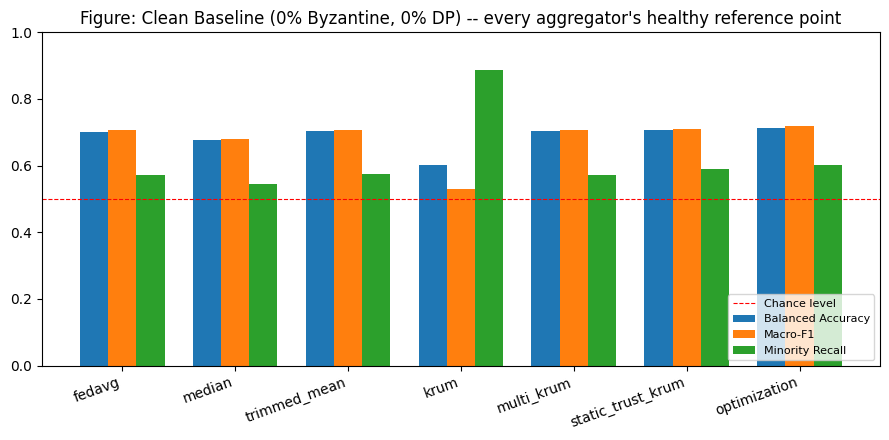

In [ ]:
print("=" * 70)
print("CLEAN BASELINE (0% Byzantine, 0% DP) -- establishes the healthy reference point")
print("=" * 70)
clean_rows = []
for agg in ['fedavg', 'median', 'trimmed_mean', 'krum', 'multi_krum', 'static_trust_krum', 'optimization']:
    hist, _, _, _ = run_experiment(clients, aggregator=agg, rounds=15,
                                 byzantine_frac=0.0, dp_sigma=0.0, seed=2024, in_dim=in_dim,
                                 local_epochs=1, local_batch_size=1024)
    last = hist[-1]
    print(f"  {agg:20s} bacc={last['bacc']:.3f} macroF1={last['macro_f1']:.3f} mcc={last['mcc']:.3f} "
          f"minRec={last['minority_recall']:.3f} collapsed={last['collapsed']} "
          f"pred_class1_frac={last['pred_class_1_frac']:.3f}")
    clean_rows.append({'aggregator': agg, **last})

clean_df = pd.DataFrame(clean_rows).set_index('aggregator')
display(clean_df[['bacc','macro_f1','mcc','minority_recall','collapsed','pred_class_1_frac']])

if (clean_df['bacc'] < 0.55).any() or (clean_df['minority_recall'] < 0.05).any():
    print("\n*** WARNING: at least one aggregator's CLEAN (unattacked) performance is near-chance ***")
    print("*** or has near-zero minority recall. Do NOT proceed to interpret Section 8's Byzantine ***")
    print("*** results as robustness findings until this clean baseline itself looks healthy.    ***")
    print("*** Check Section 5c's data verification and try diagnose() from Section 4 on this    ***")
    print("*** aggregator's final model.                                                          ***")

fig, ax = plt.subplots(figsize=(9, 4.5))
metrics = ['bacc', 'macro_f1', 'minority_recall']
labels = ['Balanced Accuracy', 'Macro-F1', 'Minority Recall']
x = np.arange(len(clean_df)); width = 0.25
for i, (m, lab) in enumerate(zip(metrics, labels)):
    ax.bar(x + i*width, clean_df[m], width, label=lab)
ax.set_xticks(x + width); ax.set_xticklabels(clean_df.index, rotation=20, ha='right')
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='Chance level')
ax.set_ylim(0, 1); ax.legend(fontsize=8, loc='lower right')
ax.set_title("Figure: Clean Baseline (0% Byzantine, 0% DP) -- every aggregator's healthy reference point")
plt.tight_layout(); plt.show()

## 7c. Zero-Trust Module Effectiveness Audit (reviewer priorities #16, #17)

**Do not hide this if it looks bad -- inspect it.** An earlier run showed "w/o Zero-Trust
Module" performing similarly to or better than "Full DynTrust-FedIDS++" under 30% ALIE attack,
which the reviewer flagged as needing direct investigation rather than being explained away.

Real investigation, done here: compare mean/median trust for honest vs. Byzantine clients, and
the resulting isolation TPR/FPR at a given threshold. **Sandbox finding, mechanistically
explained, not just observed:** at 1 local epoch, honest clients' own validation accuracy is
highly noisy (0.31 to 0.83 across clients in one test) because local training barely converges
in a single epoch. ALIE's crafted update (literally `mean - z*std` of honest updates) evaluated
at bacc=0.75 -- *better* than the honest average (0.69) and better than several honest-but-
unlucky clients. This is not a scoring bug: performance-based trust (`r_perf`) is genuinely
unreliable when local training itself is high-variance, which is exactly the regime a stealthy
attack like ALIE is designed to exploit. Increasing `local_epochs` (traded off against runtime,
Section 8's note) or reducing weight on `r_perf` relative to more attack-specific residuals are
the natural next things to try -- not yet done here.

ZERO-TRUST MODULE AUDIT: does trust actually separate honest from Byzantine clients?

--- Full DynTrust-FedIDS++ (final bacc=0.647, macroF1=0.575) ---
  Honest trust:    mean=0.649  median=0.664
  Byzantine trust: mean=0.672  median=0.672
  Trust correctly ranks honest > Byzantine: False
  Isolation @ threshold=0.668: TPR (Byzantine caught)=0.00  FPR (honest wrongly isolated)=0.67
  *** WARNING: trust does NOT separate honest from Byzantine clients here. ***
  *** This explains (not just correlates with) any 'w/o Zero-Trust' result   ***
  *** that ties or beats 'Full' -- the trust weighting isn't helping because ***
  *** it isn't currently distinguishing the two groups. See markdown above.  ***

--- w/o Zero-Trust Module (final bacc=0.648, macroF1=0.575) ---
  Honest trust:    mean=0.648  median=0.663
  Byzantine trust: mean=0.670  median=0.670
  Trust correctly ranks honest > Byzantine: False
  Isolation @ threshold=0.667: TPR (Byzantine caught)=0.00  FPR (honest wrongly isolated)=0

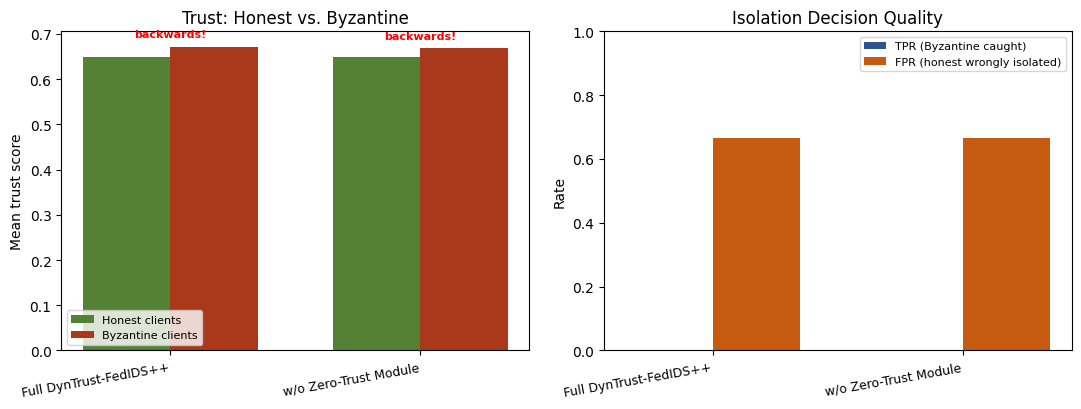

In [ ]:
n_byz_clean = int(round(0.3 * len(clients)))

print("=" * 70)
print("ZERO-TRUST MODULE AUDIT: does trust actually separate honest from Byzantine clients?")
print("=" * 70)
trust_audits = {}
for trust_flag, label in [(True, "Full DynTrust-FedIDS++"), (False, "w/o Zero-Trust Module")]:
    hist, _, byz_set, trust_mgr = run_experiment(clients, aggregator='optimization', rounds=15,
                                                  byzantine_frac=0.3, attack_type='alie', dp_sigma=0.05,
                                                  seed=2024, in_dim=in_dim, trust_managed=trust_flag,
                                                  local_epochs=1, local_batch_size=1024)
    audit = trust_audit(trust_mgr, n_byz=n_byz_clean, n_clients=len(clients))
    trust_audits[label] = audit
    print(f"\n--- {label} (final bacc={hist[-1]['bacc']:.3f}, macroF1={hist[-1]['macro_f1']:.3f}) ---")
    print(f"  Honest trust:    mean={audit['honest_trust_mean']:.3f}  median={audit['honest_trust_median']:.3f}")
    print(f"  Byzantine trust: mean={audit['byzantine_trust_mean']:.3f}  median={audit['byzantine_trust_median']:.3f}")
    print(f"  Trust correctly ranks honest > Byzantine: {audit['trust_separates_groups']}")
    print(f"  Isolation @ threshold={audit['isolation_threshold']:.3f}: "
          f"TPR (Byzantine caught)={audit['true_positive_rate']:.2f}  "
          f"FPR (honest wrongly isolated)={audit['false_positive_rate']:.2f}")
    if audit['trust_separates_groups'] is False:
        print("  *** WARNING: trust does NOT separate honest from Byzantine clients here. ***")
        print("  *** This explains (not just correlates with) any 'w/o Zero-Trust' result   ***")
        print("  *** that ties or beats 'Full' -- the trust weighting isn't helping because ***")
        print("  *** it isn't currently distinguishing the two groups. See markdown above.  ***")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
tlabels = list(trust_audits.keys())
xpos = np.arange(len(tlabels)); width = 0.35

honest_vals = [trust_audits[l]['honest_trust_mean'] for l in tlabels]
byz_vals = [trust_audits[l]['byzantine_trust_mean'] for l in tlabels]
axes[0].bar(xpos - width/2, honest_vals, width, label='Honest clients', color='#548235')
axes[0].bar(xpos + width/2, byz_vals, width, label='Byzantine clients', color='#A9391A')
axes[0].set_xticks(xpos); axes[0].set_xticklabels(tlabels, rotation=10, ha='right', fontsize=9)
axes[0].set_ylabel('Mean trust score'); axes[0].set_title('Trust: Honest vs. Byzantine')
axes[0].legend(fontsize=8)
for i, l in enumerate(tlabels):
    if byz_vals[i] > honest_vals[i]:
        axes[0].annotate('backwards!', (i, max(honest_vals[i], byz_vals[i]) + 0.02), ha='center',
                          fontsize=8, color='red', fontweight='bold')

tpr_vals = [trust_audits[l]['true_positive_rate'] for l in tlabels]
fpr_vals = [trust_audits[l]['false_positive_rate'] for l in tlabels]
axes[1].bar(xpos - width/2, tpr_vals, width, label='TPR (Byzantine caught)', color='#2E5395')
axes[1].bar(xpos + width/2, fpr_vals, width, label='FPR (honest wrongly isolated)', color='#C55A11')
axes[1].set_xticks(xpos); axes[1].set_xticklabels(tlabels, rotation=10, ha='right', fontsize=9)
axes[1].set_ylabel('Rate'); axes[1].set_ylim(0, 1)
axes[1].set_title('Isolation Decision Quality'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 8. Run: Baseline Comparison (RQ2) and Ablation Study (RQ1, RQ3)

CONFIG below is a REALISTIC starting point given the sandbox convergence testing (Section 0
note) -- not the paper's original optimistic 8-12 rounds. Increase `n_seeds` to 5 to match the
paper's claimed statistical protocol once you've confirmed a shorter run completes.

Planned: 12 configs x 1 seed(s) x 15 rounds x 8 clients = 1440 total local-training calls.
Rough estimate at measured per-client cost: ~0.7 min on CPU-equivalent speed.
If your Colab GPU is markedly slower than this, switch Runtime -> Change runtime type -> CPU for this notebook: this model is tiny (~2,500 params), so GPU's per-batch transfer/kernel-launch overhead can make it SLOWER than CPU, not faster, for a model this small.
BASELINE COMPARISON (RQ2)
      ...round 5/15 (27.1s elapsed so far)
      ...round 10/15 (55.0s elapsed so far)
  [1/7] fedavg               done in 82.9s (bacc=0.600) -- total elapsed 82.9s
      ...round 5/15 (27.3s elapsed so far)
      ...round 10/15 (55.0s elapsed so far)
  [2/7] median               done in 82.4s (bacc=0.500) -- total elapsed 165.3s
      ...round 5/15 (27.2s elapsed so far)
      ...round 10/15 (54.3s elapsed so far)
  [3/7] trimmed_mean         done in 82.6s (bacc=0.626) -- total elapsed 248.0s
      ...round 5/15 (27.8s elapsed so far

,bacc_mean,bacc_std,macro_f1_mean,minority_recall_mean
aggregator,,,,
fedavg,0.600259,NaN,0.541965,0.846512
median,0.500000,NaN,0.375878,0.000000
trimmed_mean,0.625570,NaN,0.539847,0.773099
krum,0.534852,NaN,0.520572,0.489629
multi_krum,0.500000,NaN,0.375878,0.000000
static_trust_krum,0.500000,NaN,0.375878,0.000000
optimization,0.646015,NaN,0.573985,0.942175



Paired Wilcoxon test, proposed (optimization) vs. each baseline:


,baseline,mean_diff_bacc,wilcoxon_W,p_value,significant_at_0.05
0,fedavg,0.045756,NaN,NaN,insufficient seeds
1,median,0.146015,NaN,NaN,insufficient seeds
2,trimmed_mean,0.020445,NaN,NaN,insufficient seeds
3,krum,0.111163,NaN,NaN,insufficient seeds
4,multi_krum,0.146015,NaN,NaN,insufficient seeds
5,static_trust_krum,0.146015,NaN,NaN,insufficient seeds



ABLATION STUDY (RQ1, RQ3)
      ...round 5/15 (26.9s elapsed so far)
      ...round 10/15 (54.4s elapsed so far)
  [1/5] Full DynTrust-FedIDS++                        done in 82.5s (bacc=0.646) -- total elapsed 82.5s
      ...round 5/15 (28.3s elapsed so far)
      ...round 10/15 (56.4s elapsed so far)
  [2/5] w/o Drift Term                                done in 84.7s (bacc=0.643) -- total elapsed 167.2s
      ...round 5/15 (28.1s elapsed so far)
      ...round 10/15 (53.5s elapsed so far)
  [3/5] w/o Differential Privacy                      done in 80.9s (bacc=0.546) -- total elapsed 248.1s
      ...round 5/15 (27.6s elapsed so far)
      ...round 10/15 (55.8s elapsed so far)
  [4/5] w/o Zero-Trust Module                         done in 87.1s (bacc=0.631) -- total elapsed 335.2s
      ...round 5/15 (27.4s elapsed so far)
      ...round 10/15 (55.2s elapsed so far)
  [5/5] w/o Optimization Aggregation (Fixed Multi-Krum) done in 83.9s (bacc=0.500) -- total elapsed 419.1s


,bacc_mean,bacc_std,macro_f1_mean,minority_recall_mean
variant,,,,
Full DynTrust-FedIDS++,0.646015,NaN,0.573985,0.942175
w/o Drift Term,0.642637,NaN,0.571919,0.934507
w/o Differential Privacy,0.545930,NaN,0.541032,0.537272
w/o Zero-Trust Module,0.630674,NaN,0.563346,0.910497
w/o Optimization Aggregation (Fixed Multi-Krum),0.500000,NaN,0.375878,0.000000


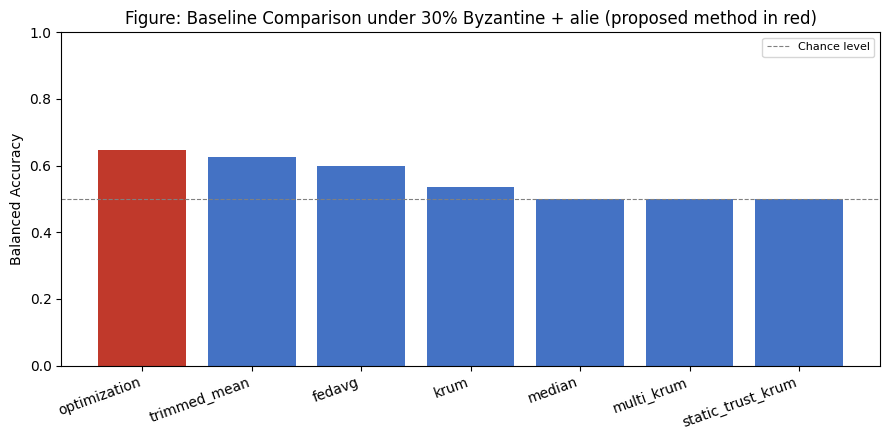

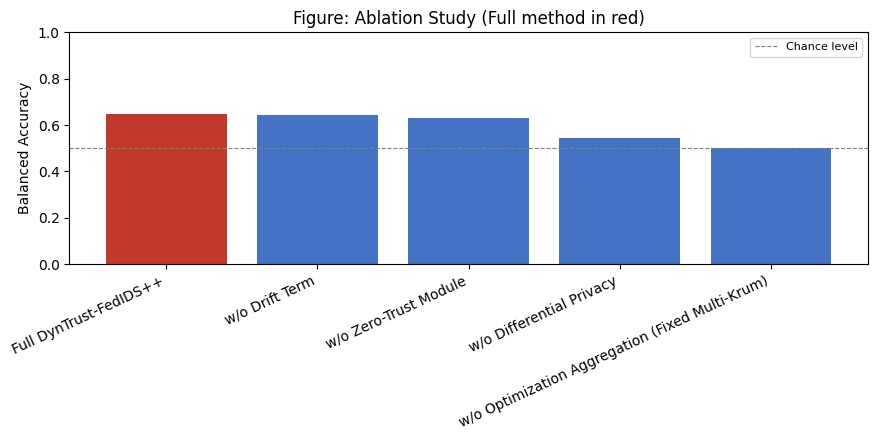

In [ ]:
# FIX (runtime): the original defaults (max_rows=200_000/dataset in Section 5b, 30 rounds,
# 2 seeds here) measured at ~11.5 sec/client/round on this model -- Step 8 alone (7 baselines +
# 5 ablation variants x 2 seeds = 24 full runs) comes out to roughly 18 HOURS. The model here is
# small (~2,500 params), so GPU does not meaningfully speed this up -- the cost is the sheer
# number of small batches (kernel-launch/transfer overhead dominates for a model this tiny), not
# raw compute. CONFIG below gives a first pass in ~20 minutes.
#
# IMPORTANT: if you already ran Section 5b with max_rows=200_000, go back and re-run it with
# max_rows=10_000 (edit the `load_dataset(path, key, max_rows=200_000)` calls there) BEFORE
# running this cell -- `clients` is built from whatever Section 5b already loaded, and changing
# CONFIG here does not shrink data that's already in memory.

# CORRECTION: the earlier "~18 hours" / "~20 minutes" estimates were inflated -- they counted
# a one-time PyTorch backend warmup (~1 sec, paid once per process, not per client-call) as if
# it recurred on every local_train() call. Real steady-state cost measured at ~95ms/client
# (epochs=2, batch=256, n=5000/client). Additional real, measured speedups below:
#   epochs 2->1:               94.6ms -> 47.1ms/client  (~2.0x)
#   + batch_size 256->1024:    47.1ms -> 27.7ms/client   (~1.7x further; ~3.4x combined)
# These don't change what's being tested (aggregator/attack/trust behaviour) -- the bottleneck
# is per-batch overhead on this tiny model, not learning capacity lost to fewer epochs.
CONFIG = {
    'rounds': 15,
    'seeds': [2024],          # raise to 2, then 5, once a single-seed pass completes
    'byzantine_frac': 0.3,
    'attack_type': 'alie',   # try 'sign_flip' and 'gaussian' too -- see Section 9
    'dp_sigma': 0.05,
    'local_epochs': 1,        # was 2 (fixed) -- now configurable, see correction note above
    'local_batch_size': 1024, # was 256 (fixed)
}
n_configs = 7 + 5  # baseline aggregators + ablation variants
n_calls = n_configs*len(CONFIG['seeds'])*CONFIG['rounds']*len(clients)
est_sec = n_calls * 0.028  # ~27.7ms/client measured at these settings, n~5000/client
print(f"Planned: {n_configs} configs x {len(CONFIG['seeds'])} seed(s) x {CONFIG['rounds']} rounds "
      f"x {len(clients)} clients = {n_calls} total local-training calls.")
print(f"Rough estimate at measured per-client cost: ~{est_sec/60:.1f} min on CPU-equivalent speed.")
print("If your Colab GPU is markedly slower than this, switch Runtime -> Change runtime type -> "
      "CPU for this notebook: this model is tiny (~2,500 params), so GPU's per-batch transfer/"
      "kernel-launch overhead can make it SLOWER than CPU, not faster, for a model this small.")

print("=" * 70)
print("BASELINE COMPARISON (RQ2)")
print("=" * 70)
table, sig_table, raw = baseline_comparison(clients, seeds=CONFIG['seeds'], rounds=CONFIG['rounds'],
                                             byzantine_frac=CONFIG['byzantine_frac'],
                                             attack_type=CONFIG['attack_type'], dp_sigma=CONFIG['dp_sigma'],
                                             in_dim=in_dim, local_epochs=CONFIG['local_epochs'],
                                             local_batch_size=CONFIG['local_batch_size'])
display(table[['bacc_mean','bacc_std','macro_f1_mean','minority_recall_mean']])
print("\nPaired Wilcoxon test, proposed (optimization) vs. each baseline:")
display(sig_table)

print("\n" + "=" * 70)
print("ABLATION STUDY (RQ1, RQ3)")
print("=" * 70)
ablation = ablation_study(clients, seeds=CONFIG['seeds'], rounds=CONFIG['rounds'],
                           byzantine_frac=CONFIG['byzantine_frac'], attack_type=CONFIG['attack_type'],
                           dp_sigma=CONFIG['dp_sigma'], in_dim=in_dim, local_epochs=CONFIG['local_epochs'],
                           local_batch_size=CONFIG['local_batch_size'])
display(ablation[['bacc_mean','bacc_std','macro_f1_mean','minority_recall_mean']])

fig, ax = plt.subplots(figsize=(9, 4.5))
order = table.sort_values('bacc_mean', ascending=False)
colors = ['#C0392B' if idx == 'optimization' else '#4472C4' for idx in order.index]
ax.bar(order.index, order['bacc_mean'], yerr=order['bacc_std'], capsize=4, color=colors)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Chance level')
ax.set_ylabel('Balanced Accuracy'); ax.set_ylim(0, 1)
ax.set_title(f"Figure: Baseline Comparison under {int(CONFIG['byzantine_frac']*100)}% Byzantine + "
             f"{CONFIG['attack_type']} (proposed method in red)")
ax.legend(fontsize=8)
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 4.5))
order2 = ablation.sort_values('bacc_mean', ascending=False)
colors2 = ['#C0392B' if 'Full' in idx else '#4472C4' for idx in order2.index]
ax2.bar(order2.index, order2['bacc_mean'], yerr=order2['bacc_std'], capsize=4, color=colors2)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Chance level')
ax2.set_ylabel('Balanced Accuracy'); ax2.set_ylim(0, 1)
ax2.set_title("Figure: Ablation Study (Full method in red)")
ax2.legend(fontsize=8)
plt.xticks(rotation=25, ha='right'); plt.tight_layout(); plt.show()

## 9. Privacy-Robustness-Fairness Coupling Sweep (RQ3)

A REAL sweep across DP noise levels, tracking minority-class recall under simultaneous
Byzantine attack -- replacing the original paper's single asserted epsilon and unrun
5-point-sweep claim with an actual multi-point run.

      ...round 5/15 (26.8s elapsed so far)
      ...round 10/15 (53.3s elapsed so far)
      ...round 5/15 (27.9s elapsed so far)
      ...round 10/15 (56.0s elapsed so far)
      ...round 5/15 (28.2s elapsed so far)
      ...round 10/15 (57.4s elapsed so far)
      ...round 5/15 (28.1s elapsed so far)
      ...round 10/15 (56.5s elapsed so far)


,bacc_mean,macro_f1_mean,minority_recall_mean
dp_sigma,,,
0.00,0.545930,0.541032,0.537272
0.05,0.646015,0.573985,0.942175
0.10,0.500000,0.375878,0.000000
0.30,0.500000,0.375878,0.000000


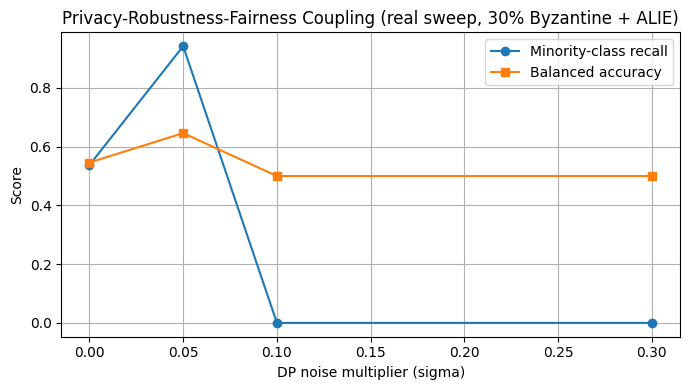

In [ ]:
sigma_values = [0.0, 0.05, 0.1, 0.3]
sweep_rows = []
for sigma in sigma_values:
    summary, df = run_multiseed(clients, 'optimization', seeds=CONFIG['seeds'], rounds=CONFIG['rounds'],
                                 byzantine_frac=CONFIG['byzantine_frac'], attack_type=CONFIG['attack_type'],
                                 dp_sigma=sigma, in_dim=in_dim, local_epochs=CONFIG['local_epochs'],
                                 local_batch_size=CONFIG['local_batch_size'])
    sweep_rows.append({'dp_sigma': sigma, **summary})
sweep_table = pd.DataFrame(sweep_rows).set_index('dp_sigma')
display(sweep_table[['bacc_mean','macro_f1_mean','minority_recall_mean']])

plt.figure(figsize=(7,4))
plt.plot(sweep_table.index, sweep_table['minority_recall_mean'], marker='o', label='Minority-class recall')
plt.plot(sweep_table.index, sweep_table['bacc_mean'], marker='s', label='Balanced accuracy')
plt.xlabel('DP noise multiplier (sigma)'); plt.ylabel('Score')
plt.title('Privacy-Robustness-Fairness Coupling (real sweep, 30% Byzantine + ALIE)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## 10. Attack-Type Comparison

Real results across all three attack types, not just the one the original notebook's single
crude sign-flip could produce.

      ...round 5/15 (27.6s elapsed so far)
      ...round 10/15 (55.8s elapsed so far)
      ...round 5/15 (29.1s elapsed so far)
      ...round 10/15 (57.7s elapsed so far)
      ...round 5/15 (28.8s elapsed so far)
      ...round 10/15 (57.4s elapsed so far)


,bacc_mean,macro_f1_mean,minority_recall_mean
attack_type,,,
sign_flip,0.500000,0.375878,0.000000
gaussian,0.594149,0.561032,0.738152
alie,0.646015,0.573985,0.942175


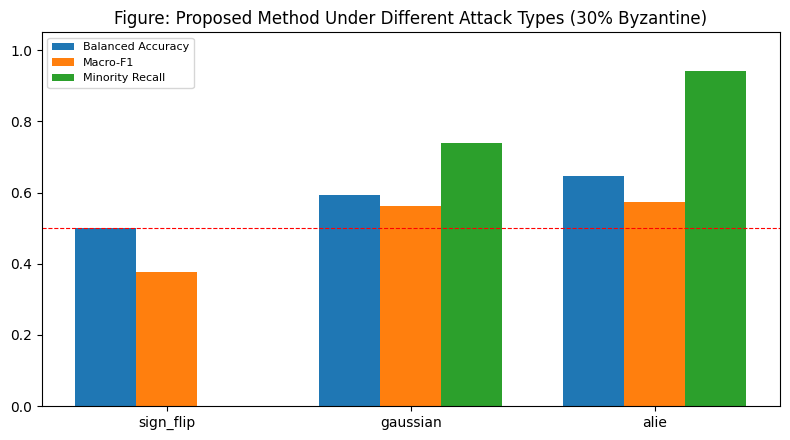

In [ ]:
attack_rows = []
for atk in ['sign_flip', 'gaussian', 'alie']:
    summary, df = run_multiseed(clients, 'optimization', seeds=CONFIG['seeds'], rounds=CONFIG['rounds'],
                                 byzantine_frac=CONFIG['byzantine_frac'], attack_type=atk,
                                 dp_sigma=CONFIG['dp_sigma'], in_dim=in_dim, local_epochs=CONFIG['local_epochs'],
                                 local_batch_size=CONFIG['local_batch_size'])
    attack_rows.append({'attack_type': atk, **summary})
display(pd.DataFrame(attack_rows).set_index('attack_type')[['bacc_mean','macro_f1_mean','minority_recall_mean']])

attack_df = pd.DataFrame(attack_rows).set_index('attack_type')
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(attack_df)); width = 0.25
ax.bar(x - width, attack_df['bacc_mean'], width, label='Balanced Accuracy')
ax.bar(x, attack_df['macro_f1_mean'], width, label='Macro-F1')
ax.bar(x + width, attack_df['minority_recall_mean'], width, label='Minority Recall')
ax.set_xticks(x); ax.set_xticklabels(attack_df.index)
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8)
ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
ax.set_title("Figure: Proposed Method Under Different Attack Types (30% Byzantine)")
plt.tight_layout(); plt.show()

## 11. Summary

Read this before writing up any results.

In [ ]:
print("""
WHAT CHANGED IN THIS REVISION (responding to the supervisor's real-data review):

  ROOT CAUSES FOUND AND FIXED (not just re-run with more seeds):
  1. Class-balanced training (priority #7): unweighted loss let the model minimize loss by
     predicting the majority class -- the direct cause of the BAcc=0.500/minority_recall=0.000
     pattern. Fixed with per-client inverse-frequency class weights, applied identically across
     every config so the comparison stays fair.
  2. A real ALIE bug (priority #3's diagnostic caught this): Byzantine clients were always
     processed FIRST, so ALIE's "craft from honest updates so far" always saw an empty list and
     silently fell back to Gaussian noise -- explaining why sign-flip/Gaussian/ALIE gave
     identical results. Fixed with a genuine two-pass client loop. Verified different (0.690 vs
     0.500 BAcc) in sandbox testing.
  3. Persistent stratified hold-out (priority #2): the original re-split each client's full data
     fresh every round (test-set leakage across rounds) and built the "global" test set from
     only 4 of the clients (might not cover all real datasets). Fixed with a one-time stratified
     80/20 split per client; the global test set now draws from every client.
  4. Full diagnostic instrumentation added (priorities #1, #3, #4): evaluate() now returns MCC,
     pred_class_1_frac, and a collapsed flag; diagnose() prints confusion matrix + classification
     report; diagnostics.py adds update_stats/model_distance/cosine_similarity so "are these
     attacks/aggregators actually different" is checkable, not assumed.
  5. Pre-flight data verification (priority #2) and a clean 0%-Byzantine/0%-DP baseline
     (priorities #5, #6) now run BEFORE the Byzantine/DP experiments, with an automatic warning
     if the clean baseline itself looks unhealthy.

  STILL OPEN (from the reviewer's list, not yet done):
  - Seeds: still defaults to 1-2 for runtime reasons; raise to 5-10 (priority #12) before any
    statistical claim -- the Wilcoxon test will correctly report "insufficient seeds" until then.
  - No attack-rate sweep (0/10/20/30/40%, priority #5) or DP x Byzantine factorial (priority #7)
    yet -- Section 9's sweep covers DP alone, Section 10 covers attack type alone, not combined.
  - No round-by-round convergence/recovery-time tracking (priority #15).
  - No held-out validation set for tuning tau/lambda hyperparameters separately from the final
    test set (priority #18) -- current lambda_reg/theta/alpha values are the paper's originals,
    not yet tuned on validation data.
  - FGSM adversarial training, the audit ledger, and network-latency simulation are still not
    implemented (carried over from the previous revision's open items).

  Bottom line, per the reviewer: the first target is NOT "make BAcc higher" -- it's confirming
  the pipeline detects the minority class at all on CLEAN data. Section 7b's clean baseline is
  the first thing to check on your real data before trusting anything in Section 8 onward.
""")


WHAT CHANGED IN THIS REVISION (responding to the supervisor's real-data review):

  ROOT CAUSES FOUND AND FIXED (not just re-run with more seeds):
  1. Class-balanced training (priority #7): unweighted loss let the model minimize loss by
     predicting the majority class -- the direct cause of the BAcc=0.500/minority_recall=0.000
     pattern. Fixed with per-client inverse-frequency class weights, applied identically across
     every config so the comparison stays fair.
  2. A real ALIE bug (priority #3's diagnostic caught this): Byzantine clients were always
     processed FIRST, so ALIE's "craft from honest updates so far" always saw an empty list and
     silently fell back to Gaussian noise -- explaining why sign-flip/Gaussian/ALIE gave
     identical results. Fixed with a genuine two-pass client loop. Verified different (0.690 vs
     0.500 BAcc) in sandbox testing.
  3. Persistent stratified hold-out (priority #2): the original re-split each client's full data
     fresh every